# Comparing to what we thought we knew about these colony sizes 

Ok for this code, I want to compare our male huddle breeding estimate to what we previously thought the size of the colony was "avg_size" data
from the original dfRFD file (dfRFD_with_predictions_cleaned_final) and the bp estimate from dfHuddle export file 

I have refined how I claculated avg_size - rather than using the colsz data that Michelle gave me, which I found some mistakes in, I have gone back to the publications and am recalculating the means based on the whole timeseries and SD. 

Datasets I used were: 
- Foster-Dyer et al. 2026 (7 colonies 00-24)
- Fretwell et al. 2025 (16 colonies 09-23)
- LaRue et al. 2024 (50 colonies 09-18)
- Wienecke et al. 2024 (ground counts of adults and chicks)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from scipy import stats
from scipy.optimize import minimize
from sklearn.utils import resample

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10
})

print('Imports successful')

Imports successful


In [ ]:
INPUTPATH = "/mnt/c/Users/rfo37/OneDrive - University of Canterbury/PostDoc/Population modelling/"

dfRFD = pd.read_csv(os.path.join(INPUTPATH, "Final results/Actual final results/dfRFD_with_predictions_final.csv")) #this one already contains the combined sabrina records - so no need to fix that here.

#dfHuddle = pd.read_excel(os.path.join(INPUTPATH, "dfHuddle_export_final.xlsx"))
dfHuddle = pd.read_csv(os.path.join(INPUTPATH, "Final results/Actual final results/dfHuddle_export_combined_uncertainty.csv")) 


# Accurately estimated mean size of colonies based on previous work 

## I want to take the mean and sd for the Fretwell 2025 and LaRue 2024 papers 

Take the mean for as many years that have data - 

Also combined with the estimates from other papers which report new colonies and estimated sizes (Fretwell 2026 preprint, Fretwell 2024)

In [4]:
import pandas as pd
import numpy as np
import os

# ── Load data files ────────────────────────────────────────────────────────
df_fretwell = pd.read_excel(
    os.path.join(INPUTPATH, "Fretwell_etal2025_WS09-23.xlsx")
)
df_larue = pd.read_csv(
    os.path.join(INPUTPATH, "LaRue_etal2024_colony_results09-18.csv")
)

# ── Load Foster-Dyer et al. 2026 ───────────────────────────────────────────
df_fosterdyer = pd.read_csv(
    os.path.join(INPUTPATH, "Foster-Dyer_etal2026_RS_00-2024.csv")
)


In [4]:
# ── Simple site inventory and timeseries means ─────────────────────────────

# Fretwell
fretwell_simple = (df_fretwell
    .groupby("site_name")
    .agg(
        n_years    = ("year", "count"),
        year_min   = ("year", "min"),
        year_max   = ("year", "max"),
        N_mean     = ("N_mean", "mean"),
        N_sd       = ("N_mean", "std"),
    )
    .reset_index()
)
fretwell_simple["dataset"] = "Fretwell 2025"
fretwell_simple["period"]  = (fretwell_simple["year_min"].astype(str) +
                               "–" + fretwell_simple["year_max"].astype(str))

# LaRue
larue_simple = (df_larue
    .groupby("site_name")
    .agg(
        n_years    = ("year", "count"),
        year_min   = ("year", "min"),
        year_max   = ("year", "max"),
        N_mean     = ("N_mean", "mean"),
        N_sd       = ("N_mean", "std"),
    )
    .reset_index()
)
larue_simple["dataset"] = "LaRue 2024"
larue_simple["period"]  = (larue_simple["year_min"].astype(str) +
                            "–" + larue_simple["year_max"].astype(str))

# Foster-Dyer
fosterdyer_simple = (df_fosterdyer
    .groupby("site_name")
    .agg(
        n_years    = ("year", "count"),
        year_min   = ("year", "min"),
        year_max   = ("year", "max"),
        N_mean     = ("N_mean", "mean"),
        N_sd       = ("N_mean", "std"),
    )
    .reset_index()
)
fosterdyer_simple["dataset"] = "Foster-Dyer 2026"
fosterdyer_simple["period"]  = (fosterdyer_simple["year_min"].astype(str) +
                                 "–" + fosterdyer_simple["year_max"].astype(str))

# ── Combine all three ──────────────────────────────────────────────────────
df_all = pd.concat([fretwell_simple, larue_simple, fosterdyer_simple],
                    ignore_index=True)


# ──  print long format — easier to read ────────────────────────────────
print(f"\n{'='*75}")
print("LONG FORMAT — mean count per site per dataset")
print(f"{'='*75}")
print(f"{'Site':<25} {'Dataset':<20} {'N_mean':>10} {'N_sd':>10} "
      f"{'n_years':>8} {'Period'}")
print("-" * 80)
for _, r in df_all.sort_values(["site_name", "dataset"]).iterrows():
    print(f"{r['site_name']:<25} {r['dataset']:<20} "
          f"{r['N_mean']:>10,.0f} {r['N_sd']:>10,.0f} "
          f"{int(r['n_years']):>8} {r['period']}")

# ── Export ─────────────────────────────────────────────────────────────────
#Saving to csv - I then edited this csv to combine the different data sources and the edited version is what is used from this point onward
#df_all.to_csv(
#    os.path.join(INPUTPATH, "Final results/literature_colony_means_long.csv"),
#    index=False,
#    float_format="%.0f",
#    encoding="utf-8-sig"  # adds BOM so Excel reads UTF-8 correctly
#)
print(f"\nExported long format CSV")


LONG FORMAT — mean count per site per dataset
Site                      Dataset                  N_mean       N_sd  n_years Period
--------------------------------------------------------------------------------
Amanda                    LaRue 2024                4,428        655       10 2009–2018
Amundsen                  LaRue 2024                   60         46       10 2009–2018
Astrid                    LaRue 2024                3,217        421       10 2009–2018
Atka                      Fretwell 2025             4,522      1,438       15 2009–2023
Atka                      LaRue 2024                6,960      1,768       10 2009–2018
Auster                    LaRue 2024                4,019        907       10 2009–2018
Barrier                   LaRue 2024                  282        162       10 2009–2018
Bear                      LaRue 2024                3,728      1,469       10 2009–2018
Beaufort                  Foster-Dyer 2026          1,019        403       25 2000–

## Adding in Wienecke most recent counts from 2022

Wienecke et al. 2024

In [5]:
# ── Wienecke et al. 2024 — manual entry from Table A1 ─────────────────────
df_wienecke = pd.DataFrame([
    {"colony_name": "Kloa",          "date": "2022-09-22", "year": 2022,
     "method": "Ground photography",
     "n_adults": 3470,  "n_chicks": np.nan},
    {"colony_name": "Fold",          "date": "2022-09-20", "year": 2022,
     "method": "Ground photography",
     "n_adults": 361,   "n_chicks": 234},
    {"colony_name": "Darnley",       "date": "2022-11-03", "year": 2022,
     "method": "Aerial photography",
     "n_adults": 1378,  "n_chicks": 7707},
    {"colony_name": "Amanda",        "date": "2022-11-23", "year": 2022,
     "method": "Aerial photography",
     "n_adults": 1424,  "n_chicks": 10485},
    {"colony_name": "West Ice Shelf","date": "2022-11-03", "year": 2022,
     "method": "Aerial photography",
     "n_adults": 2480,  "n_chicks": 7786},
    {"colony_name": "Posadowsky",    "date": "2022-11-03", "year": 2022,
     "method": "Aerial photography",
     "n_adults": 123,   "n_chicks": 155},
    {"colony_name": "Shackleton",    "date": "2022-12-06", "year": 2022,
     "method": "Aerial photography",
     "n_adults": 1339,  "n_chicks": 10738},
    {"colony_name": "Bowman",        "date": "2022-12-06", "year": 2022,
     "method": "Aerial photography",
     "n_adults": 399,   "n_chicks": 2372},
    {"colony_name": "Peterson",      "date": "2022-12-02", "year": 2022,
     "method": "Aerial photography",
     "n_adults": np.nan, "n_chicks": np.nan,
     "notes": "ice broke out in November"},
    {"colony_name": "Sabrina",       "date": "2022-12-02", "year": 2022,
     "method": "Aerial photography",
     "n_adults": 672,   "n_chicks": 4278},
])

df_wienecke["date"]   = pd.to_datetime(df_wienecke["date"])
df_wienecke["source"] = "Wienecke et al. 2024"
df_wienecke["season"] = "spring"

# Total count where available
df_wienecke["n_total"] = df_wienecke["n_adults"].fillna(0) + df_wienecke["n_chicks"].fillna(0)
df_wienecke.loc[df_wienecke["n_adults"].isna() & df_wienecke["n_chicks"].isna(),
                "n_total"] = np.nan

print("Wienecke et al. 2024 — Table A1:")
print(df_wienecke[["colony_name", "date", "method",
                     "n_adults", "n_chicks", "n_total"]].to_string(index=False))
print(f"\nTotal adults (where available): {df_wienecke['n_adults'].sum():,.0f}")
print(f"Total chicks (where available): {df_wienecke['n_chicks'].sum():,.0f}")


Wienecke et al. 2024 — Table A1:
   colony_name       date             method  n_adults  n_chicks  n_total
          Kloa 2022-09-22 Ground photography    3470.0       NaN   3470.0
          Fold 2022-09-20 Ground photography     361.0     234.0    595.0
       Darnley 2022-11-03 Aerial photography    1378.0    7707.0   9085.0
        Amanda 2022-11-23 Aerial photography    1424.0   10485.0  11909.0
West Ice Shelf 2022-11-03 Aerial photography    2480.0    7786.0  10266.0
    Posadowsky 2022-11-03 Aerial photography     123.0     155.0    278.0
    Shackleton 2022-12-06 Aerial photography    1339.0   10738.0  12077.0
        Bowman 2022-12-06 Aerial photography     399.0    2372.0   2771.0
      Peterson 2022-12-02 Aerial photography       NaN       NaN      NaN
       Sabrina 2022-12-02 Aerial photography     672.0    4278.0   4950.0

Total adults (where available): 11,646
Total chicks (where available): 43,755


# Manually edited and added data to create a new datafile called est_size_AllColonies.csv 

This file contains the latest most robust estimate of colony sized based on previous research. 

## Refined avg_size data 

I have improved the methods for calculating the avg_size values, including the SD and the number of years and source that the data is from. 

I have also updated the method for estimating the size of colonies that were not estimated in our work - I want to total these to say our estimate may be added to by this much.

In [3]:
# ── Load new avg_size data ─────────────────────────────────────────────────
df_est_size = pd.read_csv(
    os.path.join(INPUTPATH, "Final data files/Actual final data/est_size_AllColonies.csv")
)

print(f"Shape: {df_est_size.shape}")
print(f"\nColumns: {df_est_size.columns.tolist()}")
print(f"\nFirst few rows:")
print(df_est_size.head(60))
print(f"\nData types:")
print(df_est_size.dtypes)
print(f"\nSite names:")
print(sorted(df_est_size.iloc[:, 0].unique()))

Shape: (71, 9)

Columns: ['site_id', 'colony_x', 'site_name', 'avg_size', 'avg_size-sd', 'source', 'years', 'n_years', 'method']

First few rows:
   site_id              colony_x   site_name  avg_size  avg_size-sd  \
0     AMAN            Amanda Bay      Amanda      4428        655.0   
1     AMUN          Amundsen Bay    Amundsen        60         46.0   
2     ASTD                Astrid      Astrid      3217        421.0   
3     ATKA                  Atka        Atka      4522       1438.0   
4     AUST                Auster      Auster      4019        907.0   
5     BARR           Barrier Bay     Barrier         0          0.0   
6     BEAN       Beaufort Island    Beaufort      1019        403.0   
7     BEAR        Bear Peninsula        Bear      3728       1469.0   
8     BOWM         Bowman Island      Bowman      1416        652.0   
9     BRYA           Bryan Coast       Bryan      1350        666.0   
10    BSON      Brownson Islands    Brownson      3686       1260.0   
11

In [7]:
# ── Check name overlap ─────────────────────────────────────────────────────
est_sites = set(df_est_size["site_name"].unique())
sar_sites  = set(dfHuddle["colony_name"].unique())

matched   = est_sites & sar_sites
unmatched_est = est_sites - sar_sites
unmatched_sar = sar_sites - est_sites

print(f"Est size sites:  {len(est_sites)}")
print(f"SAR sites:       {len(sar_sites)}")
print(f"Matched:         {len(matched)}")
print(f"\nIn est_size NOT in SAR: {sorted(unmatched_est)}")
print(f"\nIn SAR NOT in est_size: {sorted(unmatched_sar)}")

#Colonies that aren't included in the SAR_sites dataset are those that we could not estimate. 
#We want to take those data and sum them to estimate the total birds possibly missed in our study 



Est size sites:  71
SAR sites:       55
Matched:         55

In est_size NOT in SAR: ['Barrier', 'Bryan', 'Case', 'Darlington', 'Dion ', 'Gould', 'Halley', 'Lataday', 'Lazarev', 'Noville', 'Pfrogner', 'Phoenix', 'Ragnhild', 'Rothschild', 'Verdi', 'Verleger']

In SAR NOT in est_size: []


In [8]:

# SIZE COMPARISON DATAFRAME — dfSizeComp
# Combines SAR-derived breeding pair estimates (dfHuddle)
# with published springtime adult estimates (df_est_size)
# Adds breeding adults column (breeding pairs × 2)
# Run this cell before any size comparison plots

dfSizeComp = dfHuddle[[
    "colony_name", "lat", "lon",
    "count_mean", "count_median",
    "combined_se_pm", "combined_lower", "combined_upper",
    "coeff_se_pm", "obs_sem",
    "n_obs", "uncertainty_flag"
]].merge(
    df_est_size[["site_name", "avg_size", "avg_size-sd",
                  "source", "years", "n_years", "method"]],
    left_on="colony_name",
    right_on="site_name",
    how="left"
).drop(columns="site_name")

# Rename SD column
dfSizeComp = dfSizeComp.rename(columns={"avg_size-sd": "avg_size_sd"})

# Breeding adults — pairs × 2
dfSizeComp["breeding_adults_mean"]  = dfSizeComp["count_mean"]    * 2
dfSizeComp["breeding_adults_lower"] = dfSizeComp["combined_lower"] * 2
dfSizeComp["breeding_adults_upper"] = dfSizeComp["combined_upper"] * 2
dfSizeComp["breeding_adults_se"]    = dfSizeComp["combined_se_pm"] * 2

# % difference — breeding pairs vs springtime
dfSizeComp["pct_diff_pairs"] = (
    (dfSizeComp["count_mean"] - dfSizeComp["avg_size"]) /
     dfSizeComp["avg_size"] * 100
).round(1)

# % difference — breeding adults vs springtime
dfSizeComp["pct_diff_adults"] = (
    (dfSizeComp["breeding_adults_mean"] - dfSizeComp["avg_size"]) /
     dfSizeComp["avg_size"] * 100
).round(1)

# Sort by avg_size
dfSizeComp = dfSizeComp.sort_values("avg_size").reset_index(drop=True)

# ── Summary ────────────────────────────────────────────────────────────────
print(f"dfSizeComp built successfully")
print(f"  Colonies:                      {len(dfSizeComp)}")
print(f"\nTotals:")
print(f"  Springtime adults (avg_size):  {dfSizeComp['avg_size'].sum():,.0f}")
print(f"  SAR breeding pairs:            {dfSizeComp['count_mean'].sum():,.0f}")
print(f"  SAR breeding adults (×2):      {dfSizeComp['breeding_adults_mean'].sum():,.0f}")
print(f"\nBreeding pairs vs springtime adults:")
print(f"  Mean % diff:   {dfSizeComp['pct_diff_pairs'].mean():.1f}%")
print(f"  Median % diff: {dfSizeComp['pct_diff_pairs'].median():.1f}%")
print(f"\nBreeding adults (×2) vs springtime adults:")
print(f"  Mean % diff:   {dfSizeComp['pct_diff_adults'].mean():.1f}%")
print(f"  Median % diff: {dfSizeComp['pct_diff_adults'].median():.1f}%")
print(f"\nPreview:")
print(dfSizeComp[[
    "colony_name", "avg_size", "avg_size_sd",
    "count_mean", "breeding_adults_mean",
    "combined_se_pm", "breeding_adults_se",
    "pct_diff_pairs", "pct_diff_adults"
]].round(0).to_string(index=False))

dfSizeComp built successfully
  Colonies:                      55

Totals:
  Springtime adults (avg_size):  204,493
  SAR breeding pairs:            301,195
  SAR breeding adults (×2):      602,391

Breeding pairs vs springtime adults:
  Mean % diff:   105.0%
  Median % diff: 77.0%

Breeding adults (×2) vs springtime adults:
  Mean % diff:   310.0%
  Median % diff: 254.1%

Preview:
   colony_name  avg_size  avg_size_sd  count_mean  breeding_adults_mean  combined_se_pm  breeding_adults_se  pct_diff_pairs  pct_diff_adults
      Amundsen        60         46.0       291.0                 583.0            54.0               109.0           386.0            871.0
       Umbeosi       110         97.0       474.0                 947.0            45.0                90.0           330.0            761.0
    Posadowsky       123          NaN       460.0                 921.0            54.0               108.0           274.0            649.0
         Gipps       200          NaN       437.0  

In [9]:
# ── Top and bottom 5 colonies by % difference ─────────────────────────────
dfSizeComp_sorted = dfSizeComp.sort_values("pct_diff_adults")

print(f"\n{'='*65}")
print("COLONIES WITH LARGEST UNDERESTIMATES (SAR < springtime)")
print("(bottom 5 — most negative % difference)")
print(f"{'='*65}")
print(f"{'Colony':<20} {'avg_size':>10} {'±SD':>8} {'count_mean':>12} "
      f"{'±SE':>8} {'pct_diff':>10}")
print("-" * 70)
for _, r in dfSizeComp_sorted.head(5).iterrows():
    print(f"{r['colony_name']:<20} {r['avg_size']:>10,.0f} "
          f"{r['avg_size_sd']:>8,.0f} "
          f"{r['count_mean']:>12,.0f} "
          f"{r['combined_se_pm']:>8,.0f} "
          f"{r['pct_diff_adults']:>9.1f}%")

print(f"\n{'='*65}")
print("COLONIES WITH LARGEST OVERESTIMATES (SAR > springtime)")
print("(top 5 — most positive % difference)")
print(f"{'='*65}")
print(f"{'Colony':<20} {'avg_size':>10} {'±SD':>8} {'count_mean':>12} "
      f"{'±SE':>8} {'pct_diff':>10}")
print("-" * 70)
for _, r in dfSizeComp_sorted.tail(5).iterrows():
    print(f"{r['colony_name']:<20} {r['avg_size']:>10,.0f} "
          f"{r['avg_size_sd']:>8,.0f} "
          f"{r['count_mean']:>12,.0f} "
          f"{r['combined_se_pm']:>8,.0f} "
          f"{r['pct_diff_adults']:>9.1f}%")

print(f"\n{'='*65}")
print("COLONIES CLOSEST TO 1:1 (best agreement)")
print("(5 closest to 0% difference)")
print(f"{'='*65}")
dfSizeComp_closest = dfSizeComp.reindex(
    dfSizeComp["pct_diff_adults"].abs().sort_values().index
)
print(f"{'Colony':<20} {'avg_size':>10} {'±SD':>8} {'count_mean':>12} "
      f"{'±SE':>8} {'pct_diff_adults':>10}")
print("-" * 70)
for _, r in dfSizeComp_closest.head(5).iterrows():
    print(f"{r['colony_name']:<20} {r['avg_size']:>10,.0f} "
          f"{r['avg_size_sd']:>8,.0f} "
          f"{r['count_mean']:>12,.0f} "
          f"{r['combined_se_pm']:>8,.0f} "
          f"{r['pct_diff_adults']:>9.1f}%")

print(f"\n{'='*65}")
print("SUMMARY")
print(f"{'='*65}")
print(f"  Largest underestimate: "
      f"{dfSizeComp_sorted.iloc[0]['colony_name']} "
      f"({dfSizeComp_sorted.iloc[0]['pct_diff_adults']:.1f}%)")
print(f"  Largest overestimate:  "
      f"{dfSizeComp_sorted.iloc[-1]['colony_name']} "
      f"({dfSizeComp_sorted.iloc[-1]['pct_diff_adults']:.1f}%)")
print(f"  Best agreement:        "
      f"{dfSizeComp_closest.iloc[0]['colony_name']} "
      f"({dfSizeComp_closest.iloc[0]['pct_diff_adults']:.1f}%)")
print(f"  Colonies within ±20%:  "
      f"{(dfSizeComp['pct_diff_adults'].abs() <= 20).sum()} / {len(dfSizeComp)}")
print(f"  Colonies within ±50%:  "
      f"{(dfSizeComp['pct_diff_adults'].abs() <= 50).sum()} / {len(dfSizeComp)}")


COLONIES WITH LARGEST UNDERESTIMATES (SAR < springtime)
(bottom 5 — most negative % difference)
Colony                 avg_size      ±SD   count_mean      ±SE   pct_diff
----------------------------------------------------------------------
Vanhoeffen                5,000      nan        1,636      849     -34.5%
Cruzen                    1,000      nan          412       46     -17.5%
Beaufort                  1,019      403          564       67      10.7%
Coulman                  21,375    5,727       16,088    2,521      50.5%
Smyley                    2,792    1,160        2,289      237      64.0%

COLONIES WITH LARGEST OVERESTIMATES (SAR > springtime)
(top 5 — most positive % difference)
Colony                 avg_size      ±SD   count_mean      ±SE   pct_diff
----------------------------------------------------------------------
Bowman                    1,416      652        5,188      413     632.8%
Posadowsky                  123      nan          460       54     648.7%
Um

In [10]:
# 10 colonies where SAR breeding pair estimate is smallest relative to avg_size
smallest_diff = dfSizeComp.nsmallest(10, "pct_diff_adults")[
    ["colony_name", "avg_size", "avg_size_sd", 
     "count_mean", "combined_se_pm", "pct_diff_adults",
     "source", "years"]
].round(0)

print("10 colonies with largest underestimates (SAR < springtime avg_size):")
print(smallest_diff.to_string(index=False))

10 colonies with largest underestimates (SAR < springtime avg_size):
colony_name  avg_size  avg_size_sd  count_mean  combined_se_pm  pct_diff_adults                  source     years
 Vanhoeffen      5000          NaN      1636.0           849.0            -34.0           Fretwell 2024 2018-2022
     Cruzen      1000          NaN       412.0            46.0            -18.0 Fretwell & Trathan 2020      2019
   Beaufort      1019        403.0       564.0            67.0             11.0 Foster-Dyer et al. 2026 2000–2024
    Coulman     21375       5727.0     16088.0          2521.0             50.0 Foster-Dyer et al. 2026 2005–2024
     Smyley      2792       1160.0      2289.0           237.0             64.0    Fretwell et al. 2025 2009–2023
    Colbeck     25979       8669.0     21418.0          2911.0             65.0 Foster-Dyer et al. 2026 2005–2024
      Davis      2220        309.0      1983.0           349.0             79.0       LaRue et al. 2024 2009–2018
 Washington     122

In [11]:
# ── Unsampled colonies — in est_size but not in SAR ───────────────────────
df_unsampled = df_est_size[df_est_size["site_name"].isin(unmatched_est)].copy()

print(f"\n{'='*60}")
print("UNSAMPLED COLONIES — in est_size but no SAR coverage")
print(f"{'='*60}")
print(df_unsampled[[
    "site_name", "avg_size", "avg_size-sd",
    "source", "years", "n_years"
]].sort_values("avg_size", ascending=False).to_string(index=False))

# Totals
total_unsampled_mean = df_unsampled["avg_size"].sum()
total_unsampled_sd   = np.sqrt((df_unsampled["avg_size-sd"] ** 2).sum())

print(f"\nUnsampled colony totals:")
print(f"  n colonies:          {len(df_unsampled)}")
print(f"  Total avg_size:      {total_unsampled_mean:,.0f} individuals")
print(f"  Combined SD ±:       {total_unsampled_sd:,.0f} individuals")

# Compare to SAR total
sar_total            = dfSizeComp["count_mean"].sum()
sar_combined_se      = np.sqrt((dfSizeComp["combined_se_pm"] ** 2).sum())

print(f"\nSAR sampled total:")
print(f"  n colonies:          {len(dfSizeComp)}")
print(f"  Total count_mean:    {sar_total:,.0f} individuals")
print(f"  Combined SE ±:       {sar_combined_se:,.0f} individuals")

# Grand total
grand_total    = sar_total + total_unsampled_mean
grand_total_se = np.sqrt(sar_combined_se ** 2 + total_unsampled_sd ** 2)

print(f"\nGrand total (SAR + unsampled literature estimates):")
print(f"  Total:               {grand_total:,.0f} individuals")
print(f"  Combined SE ±:       {grand_total_se:,.0f} individuals")
print(f"  Unsampled as % of SAR total: "
      f"{total_unsampled_mean / sar_total * 100:.1f}%")
print(f"\nNote: unsampled estimates from mixed methods and years")
print(f"({df_unsampled['years'].unique()}) — treat grand total with caution")



UNSAMPLED COLONIES — in est_size but no SAR coverage
 site_name  avg_size  avg_size-sd                   source     years  n_years
  Ragnhild      4784       1481.0        LaRue et al. 2024 2009–2018       10
     Gould      3481        926.0     Fretwell et al. 2025 2009–2023       15
   Noville      2986        777.0        LaRue et al. 2024 2009–2018       10
     Verdi      1500        500.0  Fretwell & Trathan 2020      2019        1
  Pfrogner      1500        500.0  Fretwell & Trathan 2020      2019        1
   Lataday      1400        500.0 Fretwell et al. preprint      2024        1
     Bryan      1350        666.0     Fretwell et al. 2025 2009–2023       15
   Phoenix      1350        500.0 Fretwell et al. preprint      2025        1
    Halley       841        799.0     Fretwell et al. 2025      2023        1
Rothschild       828        267.0     Fretwell et al. 2025 2009–2023       15
      Case       750        250.0 Fretwell et al. preprint      2023        1
  Verleger

## Modifying Figure 3

The comparison against avg_size and breeding pairs, we want to double the breeding pairs estimate so it is individuals (2x bp =breeding adults) so it is comparable with the individuals count in spring. 

We want to keep only panel B, flip it, and show how different the actual number of birds is to what we think when we count in spring. 




In [12]:
# Check which colonies have NaN in key columns
print(dfSizeComp[dfSizeComp[["avg_size", "avg_size_sd", 
                               "breeding_adults_mean", 
                               "breeding_adults_se"]].isna().any(axis=1)][
    ["colony_name", "avg_size", "avg_size_sd", 
     "breeding_adults_mean", "breeding_adults_se"]
])

       colony_name  avg_size  avg_size_sd  breeding_adults_mean  \
2       Posadowsky       123          NaN                920.88   
3            Gipps       200          NaN                874.68   
4         Porpoise       200          NaN               1415.18   
6             Yule       300          NaN               1079.98   
10         Sabrina       672          NaN              11208.04   
13          Cruzen      1000          NaN                824.62   
24  West Ice Shelf      2480          NaN              15625.94   
46      Vanhoeffen      5000          NaN               3272.76   

    breeding_adults_se  
2               107.74  
3               122.12  
4               226.08  
6               127.42  
10             1970.00  
13               92.80  
24             1840.08  
46             1697.36  


Non-VHR colonies (13):
['Casey', 'Cruzen', 'Gates', 'Gipps', 'Karelin', 'Ninnis', 'Pointsett', 'Porpoise', 'Posadowsky', 'Sabrina', 'Vanhoeffen', 'West Ice Shelf', 'Yule']

Method breakdown:
method
Aerial count     3
Sentinel-2       8
VHR             42
VHR count        2
Name: colony_name, dtype: int64


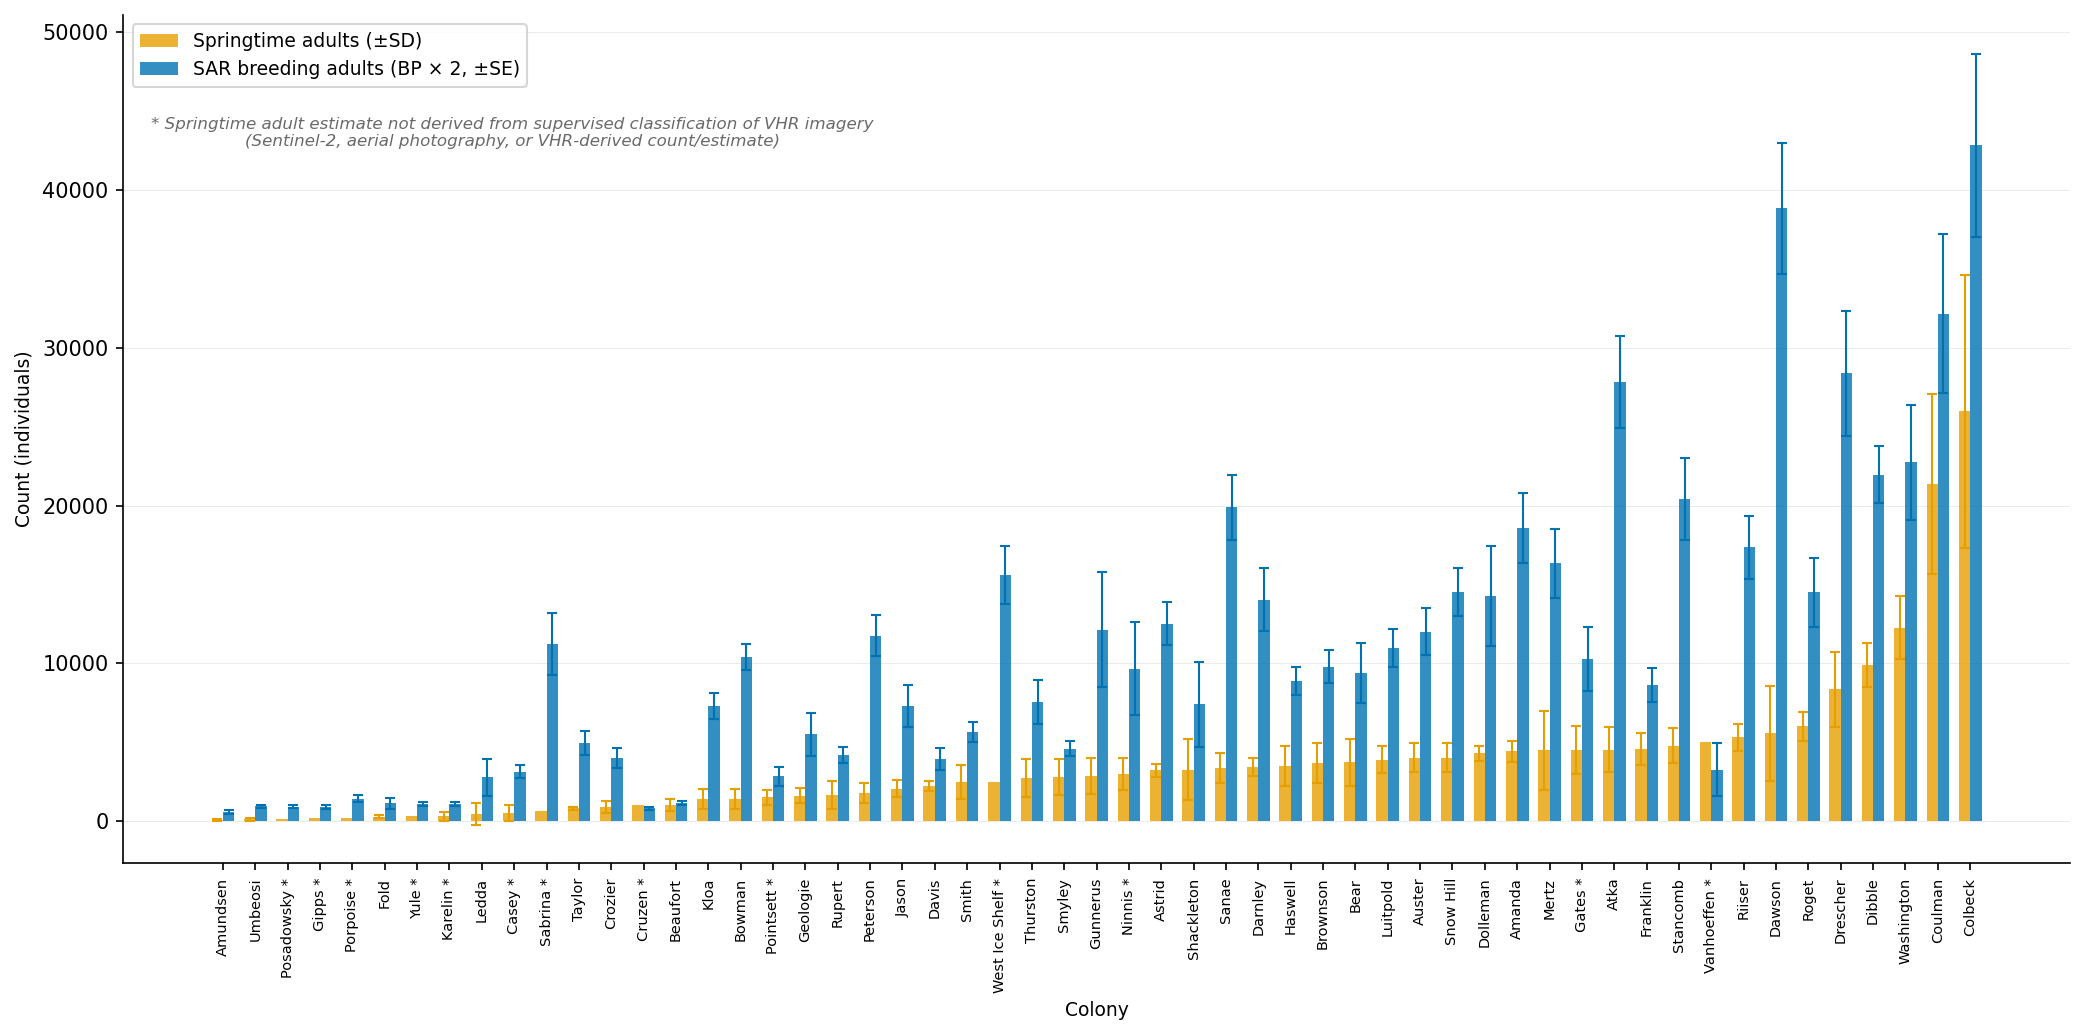

In [13]:
# ── Plot — vertical bar chart ──────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 7))

# Sort and reset index to ensure alignment
dfPlot = dfSizeComp.sort_values("avg_size").dropna(subset=[
    "avg_size", #"avg_size_sd", 
    "breeding_adults_mean", "breeding_adults_se"
]).reset_index(drop=True)
#dfPlot = dfSizeComp.sort_values("avg_size").reset_index(drop=True)
colony_order = dfPlot["colony_name"].tolist()
bar_width = 0.35

for x, (_, r) in enumerate(dfPlot.iterrows()):

    # avg_size bar with SD
    ax.bar(x - bar_width/2, r["avg_size"],
           width=bar_width, color="#E69F00",
           alpha=0.8,
           label="Springtime adults (±SD)" if x == 0 else "")
    ax.errorbar(x - bar_width/2, r["avg_size"],
                yerr=r["avg_size_sd"],
                fmt="none", color="#E69F00",
                linewidth=1, capsize=2.5, zorder=4)

    # breeding adults bar with combined SE × 2
    ax.bar(x + bar_width/2, r["breeding_adults_mean"],
           width=bar_width, color="#0072B2",
           alpha=0.8,
           label="SAR breeding adults (BP × 2, ±SE)" if x == 0 else "")
    ax.errorbar(x + bar_width/2, r["breeding_adults_mean"],
                yerr=r["breeding_adults_se"],
                fmt="none", color="#0072B2",
                linewidth=1, capsize=2.5, zorder=4)

ax.set_xticks(range(len(colony_order)))
ax.set_xticklabels(colony_order, rotation=90, fontsize=8)
ax.set_ylabel("Count (individuals)", fontsize=9)
ax.set_xlabel("Colony", fontsize=9)

ax.legend(fontsize=9, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linewidth=0.3, alpha=0.4)
ax.set_axisbelow(True)

# Standardise method names — strip whitespace
df_est_size["method"] = df_est_size["method"].str.strip()
dfSizeComp["method"]  = dfSizeComp["method"].str.strip()

# Identify non-VHR colonies — star anything that isn't pure VHR
non_vhr = set(dfSizeComp[dfSizeComp["method"] != "VHR"]["colony_name"].tolist())
print(f"Non-VHR colonies ({len(non_vhr)}):")
print(sorted(non_vhr))
print(f"\nMethod breakdown:")
print(dfSizeComp.groupby("method")["colony_name"].count())

# Starred x-axis labels
colony_labels_starred = [
    f"{c} *" if c in non_vhr else c
    for c in [r["colony_name"] for _, r in dfPlot.iterrows()]
]

ax.set_xticks(range(len(colony_labels_starred)))
ax.set_xticklabels(colony_labels_starred, rotation=90, fontsize=7)

ax.text(0.2, 0.88,
        "* Springtime adult estimate not derived "
         "from supervised classification of VHR imagery\n"
         "(Sentinel-2, aerial photography, or VHR-derived count/estimate)",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=8, color="dimgray", style="italic")

plt.tight_layout()
plt.savefig(os.path.join(INPUTPATH,
            "Final results/Actual final results/fig_breeding_adults_vs_springtime.png"),
            bbox_inches="tight", dpi=300)
plt.show()

Non-VHR colonies (13):
['Casey', 'Cruzen', 'Gates', 'Gipps', 'Karelin', 'Ninnis', 'Pointsett', 'Porpoise', 'Posadowsky', 'Sabrina', 'Vanhoeffen', 'West Ice Shelf', 'Yule']

Method breakdown:
method
Aerial count     3
Sentinel-2       8
VHR             42
VHR count        2
Name: colony_name, dtype: int64


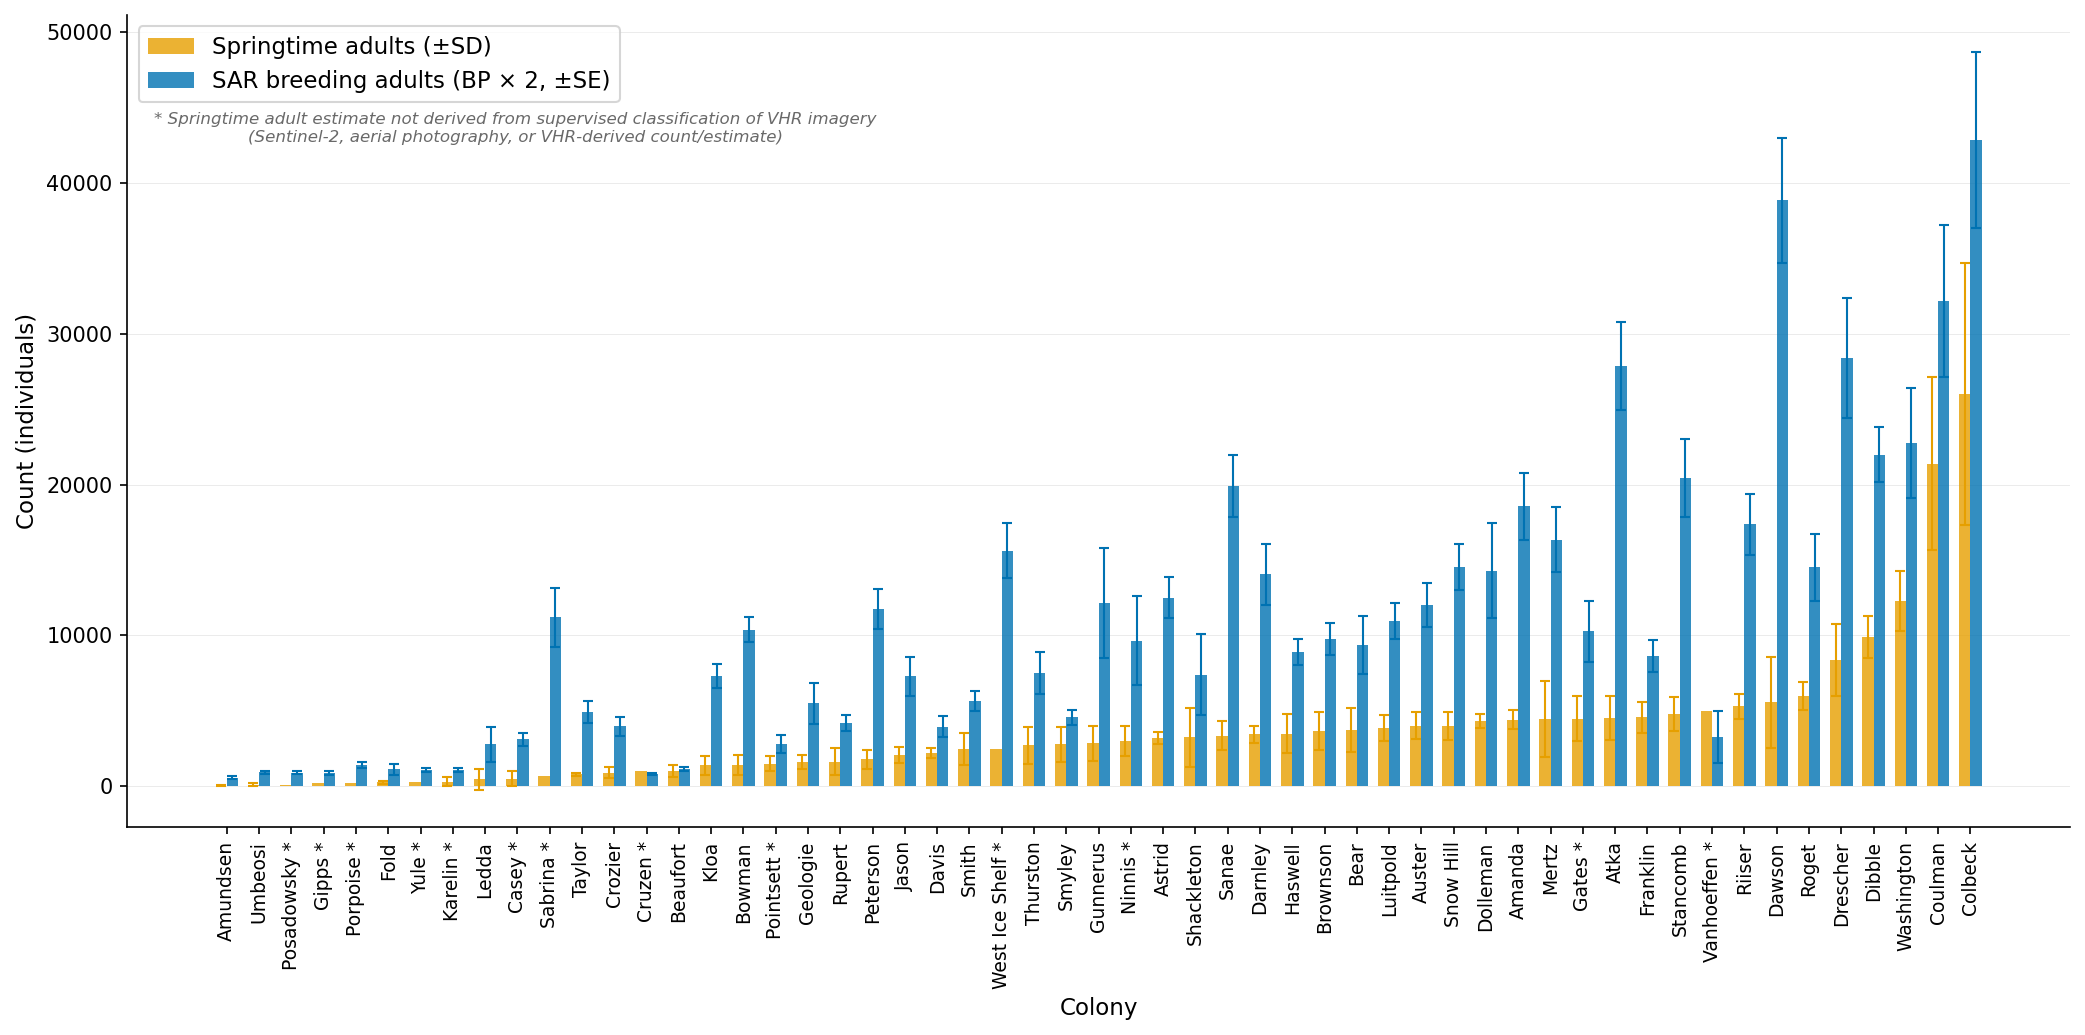

In [15]:
# ── Plot — vertical bar chart ──────────────────────────────────────────────
#Final for publication, increasing the text size and correcting spelling of some names 

# ── Colony name corrections for display ────────────────────────────────────
name_corrections = {
    "Geologie":    "Géologie",
    "Stancomb":    "Stancomb-Wills",
    "Pointsett":    "Poinsett",
    # "Vanhoeffen":  "Vanhoffen",
    # "Drescher":    "Drescher Inlet",
}
#Check Umbeosi and wait for peter's response



fig, ax = plt.subplots(figsize=(14, 7))

# Sort and reset index to ensure alignment
dfPlot = dfSizeComp.sort_values("avg_size").dropna(subset=[
    "avg_size", #"avg_size_sd", 
    "breeding_adults_mean", "breeding_adults_se"
]).reset_index(drop=True)
#dfPlot = dfSizeComp.sort_values("avg_size").reset_index(drop=True)
colony_order = dfPlot["colony_name"].tolist()
bar_width = 0.35

for x, (_, r) in enumerate(dfPlot.iterrows()):

    # avg_size bar with SD
    ax.bar(x - bar_width/2, r["avg_size"],
           width=bar_width, color="#E69F00",
           alpha=0.8,
           label="Springtime adults (±SD)" if x == 0 else "")
    ax.errorbar(x - bar_width/2, r["avg_size"],
                yerr=r["avg_size_sd"],
                fmt="none", color="#E69F00",
                linewidth=1, capsize=2.5, zorder=4)

    # breeding adults bar with combined SE × 2
    ax.bar(x + bar_width/2, r["breeding_adults_mean"],
           width=bar_width, color="#0072B2",
           alpha=0.8,
           label="SAR breeding adults (BP × 2, ±SE)" if x == 0 else "")
    ax.errorbar(x + bar_width/2, r["breeding_adults_mean"],
                yerr=r["breeding_adults_se"],
                fmt="none", color="#0072B2",
                linewidth=1, capsize=2.5, zorder=4)

ax.set_xticks(range(len(colony_order)))
ax.set_xticklabels(colony_order, rotation=90, fontsize=10)
ax.set_ylabel("Count (individuals)", fontsize=11)
ax.set_xlabel("Colony", fontsize=11)

ax.legend(fontsize=11, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linewidth=0.3, alpha=0.4)
ax.set_axisbelow(True)

# Standardise method names — strip whitespace
df_est_size["method"] = df_est_size["method"].str.strip()
dfSizeComp["method"]  = dfSizeComp["method"].str.strip()

# Identify non-VHR colonies — star anything that isn't pure VHR
non_vhr = set(dfSizeComp[dfSizeComp["method"] != "VHR"]["colony_name"].tolist())
print(f"Non-VHR colonies ({len(non_vhr)}):")
print(sorted(non_vhr))
print(f"\nMethod breakdown:")
print(dfSizeComp.groupby("method")["colony_name"].count())

# Starred x-axis labels
#colony_labels_starred = [
#    f"{c} *" if c in non_vhr else c
#    for c in [r["colony_name"] for _, r in dfPlot.iterrows()]
#]
# Build corrected and starred labels
colony_labels_final = []
for _, r in dfPlot.iterrows():
    name = name_corrections.get(r["colony_name"], r["colony_name"])
    if r["colony_name"] in non_vhr:
        name = f"{name} *"
    colony_labels_final.append(name)

ax.set_xticks(range(len(colony_labels_starred)))
ax.set_xticklabels(colony_labels_starred, rotation=90, fontsize=9)

ax.text(0.2, 0.88,
        "* Springtime adult estimate not derived "
         "from supervised classification of VHR imagery\n"
         "(Sentinel-2, aerial photography, or VHR-derived count/estimate)",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=8, color="dimgray", style="italic")

plt.tight_layout()
plt.savefig(os.path.join(INPUTPATH,
            "Final results/Actual final results/fig_breeding_adults_vs_springtime_v2.png"),
            bbox_inches="tight", dpi=600)
plt.show()

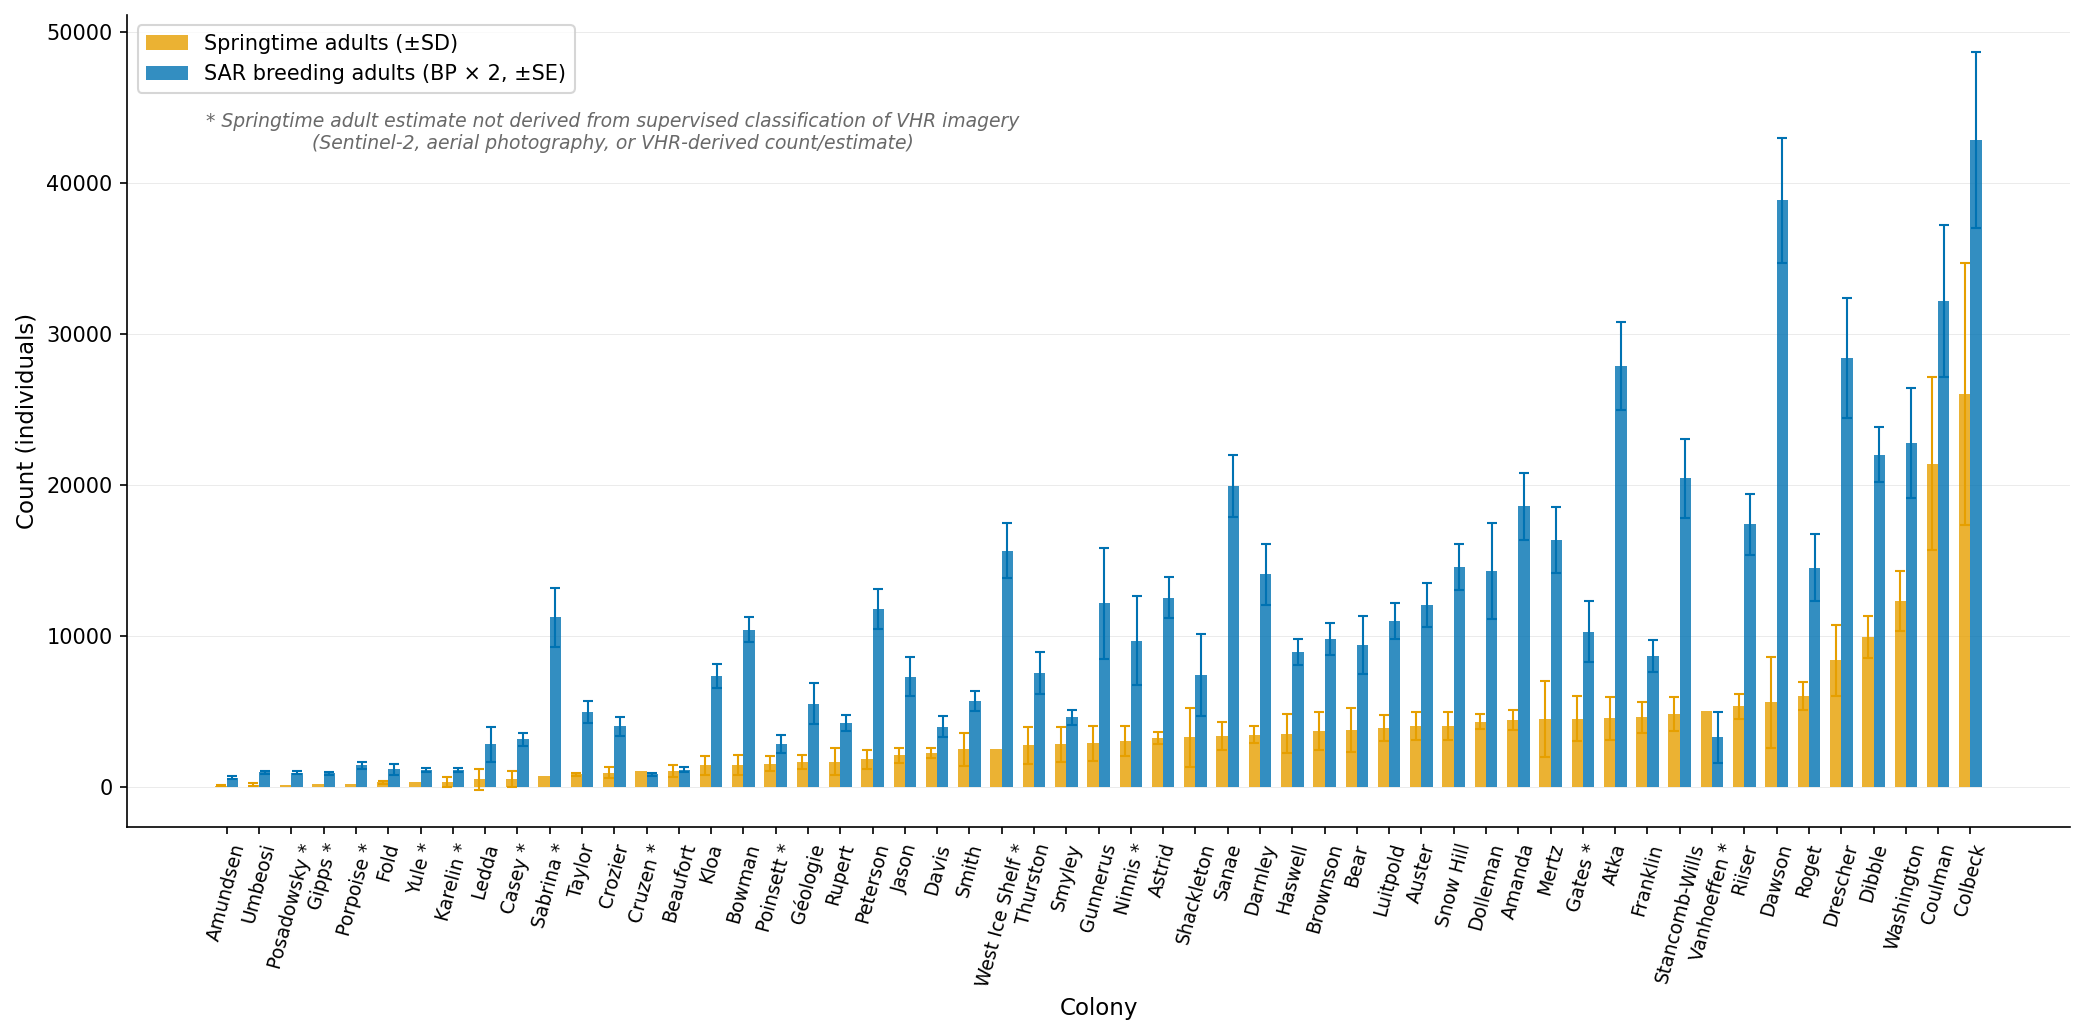

In [21]:
#Final for publication, increasing the text size and correcting spelling of some names 

# ── Colony name corrections for display ────────────────────────────────────
name_corrections = {
    "Geologie":    "Géologie",
    "Stancomb":    "Stancomb-Wills",
    "Pointsett":    "Poinsett",
    # "Vanhoeffen":  "Vanhoffen",
    # "Drescher":    "Drescher Inlet",
}
#Check Umbeosi and wait for peter's response


# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))  # slightly larger figure

dfPlot = dfSizeComp.sort_values("avg_size").dropna(subset=[
    "avg_size",
    "breeding_adults_mean", "breeding_adults_se"
]).reset_index(drop=True)
colony_order = dfPlot["colony_name"].tolist()
bar_width = 0.35

for x, (_, r) in enumerate(dfPlot.iterrows()):
    ax.bar(x - bar_width/2, r["avg_size"],
           width=bar_width, color="#E69F00", alpha=0.8,
           label="Springtime adults (±SD)" if x == 0 else "")
    ax.errorbar(x - bar_width/2, r["avg_size"],
                yerr=r["avg_size_sd"],
                fmt="none", color="#E69F00",
                linewidth=1, capsize=2.5, zorder=4)
    ax.bar(x + bar_width/2, r["breeding_adults_mean"],
           width=bar_width, color="#0072B2", alpha=0.8,
           label="SAR breeding adults (BP × 2, ±SE)" if x == 0 else "")
    ax.errorbar(x + bar_width/2, r["breeding_adults_mean"],
                yerr=r["breeding_adults_se"],
                fmt="none", color="#0072B2",
                linewidth=1, capsize=2.5, zorder=4)

# Standardise method names
df_est_size["method"] = df_est_size["method"].str.strip()
dfSizeComp["method"]  = dfSizeComp["method"].str.strip()
non_vhr = set(dfSizeComp[dfSizeComp["method"] != "VHR"]["colony_name"].tolist())

# Build corrected and starred labels
colony_labels_final = []
for _, r in dfPlot.iterrows():
    name = name_corrections.get(r["colony_name"], r["colony_name"])
    if r["colony_name"] in non_vhr:
        name = f"{name} *"
    colony_labels_final.append(name)

ax.set_xticks(range(len(colony_labels_final)))
ax.set_xticklabels(colony_labels_final, rotation=75, fontsize=9)  # increased from 7
ax.set_ylabel("Count (individuals)", fontsize=11)                  # increased from 9
ax.set_xlabel("Colony", fontsize=11)                               # increased from 9
ax.legend(fontsize=10, loc="upper left")                           # increased from 9
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linewidth=0.3, alpha=0.4)
ax.set_axisbelow(True)

ax.text(0.25, 0.88,
        "* Springtime adult estimate not derived "
        "from supervised classification of VHR imagery\n"
        "(Sentinel-2, aerial photography, or VHR-derived count/estimate)",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=9, color="dimgray", style="italic")   # increased from 8

plt.tight_layout()
plt.savefig(os.path.join(INPUTPATH,
            "Final results/Actual final results/fig_breeding_adults_vs_springtime_v3.png"),
            bbox_inches="tight", dpi=300)
plt.show()

SAR colonies:       55
Unsampled colonies: 14
Total:              69


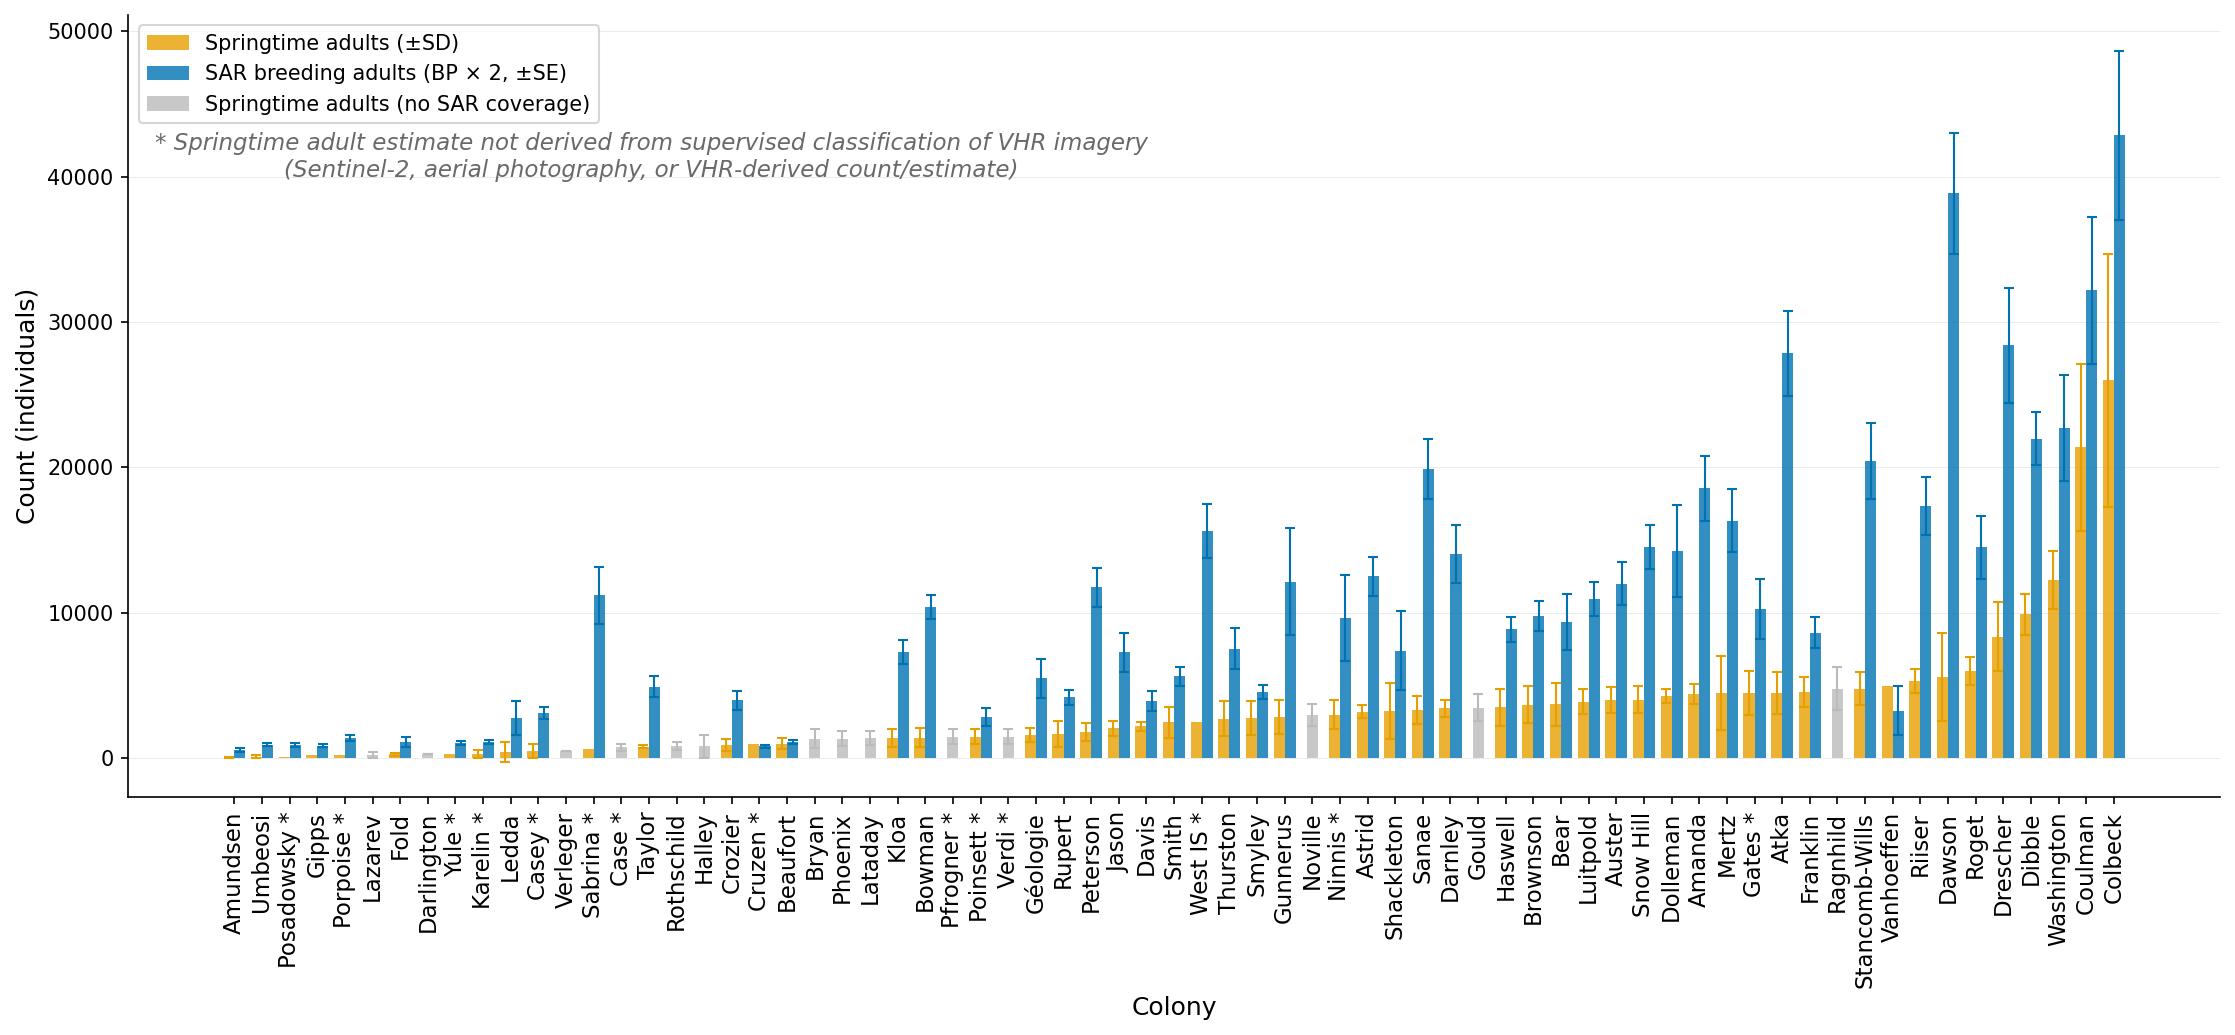


Total springtime adults — SAR colonies:      204,493
Total SAR breeding adults (pairs × 2):       602,391
Total springtime adults — unsampled:         21,796


In [31]:
#Final for supps material of publication, increasing the text size and correcting spelling of some names 

# ── Colony name corrections for display ────────────────────────────────────
name_corrections = {
    "Geologie":    "Géologie",
    "Stancomb":    "Stancomb-Wills",
    "Pointsett":    "Poinsett",
    "West Ice Shelf": "West IS",
}
#Check Umbeosi and wait for peter's response


# ── Prepare data — SAR colonies + unsampled colonies ──────────────────────
dfPlot_SAR = dfSizeComp.dropna(subset=[
    "avg_size",
    "breeding_adults_mean", "breeding_adults_se"
]).copy()
dfPlot_SAR["has_SAR"] = True

df_unsampled_plot = df_est_size[
    df_est_size["site_name"].isin(unmatched_est)
].copy().rename(columns={
    "site_name":   "colony_name",
    "avg_size-sd": "avg_size_sd"
})
df_unsampled_plot["has_SAR"]              = False
df_unsampled_plot["breeding_adults_mean"] = np.nan
df_unsampled_plot["breeding_adults_se"]   = np.nan

dfPlot_all = pd.concat(
    [dfPlot_SAR, df_unsampled_plot],
    ignore_index=True
).sort_values("avg_size").reset_index(drop=True)

dfPlot_all = dfPlot_all[dfPlot_all["avg_size"] > 0].reset_index(drop=True)

print(f"SAR colonies:       {dfPlot_all['has_SAR'].sum()}")
print(f"Unsampled colonies: {(~dfPlot_all['has_SAR']).sum()}")
print(f"Total:              {len(dfPlot_all)}")

# ── Standardise method names and identify non-VHR ─────────────────────────
df_est_size["method"] = df_est_size["method"].str.strip()
method_lookup = df_est_size.set_index("site_name")["method"].to_dict()
vhr_methods   = {"VHR", "VHR count", "VHR estimate"}
non_vhr       = set(dfSizeComp[~dfSizeComp["method"].isin(vhr_methods)]["colony_name"].tolist())

# ── Build corrected and starred labels ────────────────────────────────────
colony_labels_final = []
for _, r in dfPlot_all.iterrows():
    name   = name_corrections.get(r["colony_name"], r["colony_name"])
    method = method_lookup.get(r["colony_name"], "VHR")
    if method.strip() not in vhr_methods:
        name = f"{name} *"
    colony_labels_final.append(name)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 7))

bar_width           = 0.4
color_avg_SAR       = "#E69F00"
color_adults_SAR    = "#0072B2"
color_avg_unsampled = "#BBBBBB"

for x, (_, r) in enumerate(dfPlot_all.iterrows()):

    if r["has_SAR"]:
        ax.bar(x - bar_width/2, r["avg_size"],
               width=bar_width, color=color_avg_SAR, alpha=0.8,
               label="Springtime adults (±SD)" if x == 0 else "")
        ax.errorbar(x - bar_width/2, r["avg_size"],
                    yerr=r["avg_size_sd"],
                    fmt="none", color=color_avg_SAR,
                    linewidth=1, capsize=2.5, zorder=4)
        ax.bar(x + bar_width/2, r["breeding_adults_mean"],
               width=bar_width, color=color_adults_SAR, alpha=0.8,
               label="SAR breeding adults (BP × 2, ±SE)" if x == 0 else "")
        ax.errorbar(x + bar_width/2, r["breeding_adults_mean"],
                    yerr=r["breeding_adults_se"],
                    fmt="none", color=color_adults_SAR,
                    linewidth=1, capsize=2.5, zorder=4)
    else:
        ax.bar(x, r["avg_size"],
               width=bar_width, color=color_avg_unsampled, alpha=0.8,
               label="Springtime adults (no SAR coverage)" 
               if x == dfPlot_all[~dfPlot_all["has_SAR"]].index[0] else "")
        ax.errorbar(x, r["avg_size"],
                    yerr=r["avg_size_sd"] if pd.notna(r["avg_size_sd"]) else 0,
                    fmt="none", color=color_avg_unsampled,
                    linewidth=1, capsize=2.5, zorder=4)

ax.set_xticks(range(len(colony_labels_final)))
ax.set_xticklabels(colony_labels_final, rotation=90, fontsize=11)
ax.set_ylabel("Count (individuals)", fontsize=12)
ax.set_xlabel("Colony", fontsize=12)
ax.legend(fontsize=10, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linewidth=0.3, alpha=0.4)
ax.set_axisbelow(True)

ax.text(0.25, 0.85,
        "* Springtime adult estimate not derived "
        "from supervised classification of VHR imagery\n"
        "(Sentinel-2, aerial photography, or VHR-derived count/estimate)",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=11, color="dimgray", style="italic")

plt.tight_layout()
plt.savefig(os.path.join(INPUTPATH,
            "Final results/Actual final results/fig_all_colonies_breeding_adults_v2.png"),
            bbox_inches="tight", dpi=300)
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────
print(f"\nTotal springtime adults — SAR colonies:      "
      f"{dfPlot_SAR['avg_size'].sum():,.0f}")
print(f"Total SAR breeding adults (pairs × 2):       "
      f"{dfPlot_SAR['breeding_adults_mean'].sum():,.0f}")
print(f"Total springtime adults — unsampled:         "
      f"{df_unsampled_plot['avg_size'].sum():,.0f}")

## I think the full one will be put into supplementary material 

In [16]:
# ── Summary statistics ─────────────────────────────────────────────────────
print(f"\nTotal springtime adults (avg_size sum):      "
      f"{dfSizeComp['avg_size'].sum():,.0f}")
print(f"Total SAR breeding adults (pairs × 2 sum):  "
      f"{dfSizeComp['breeding_adults_mean'].sum():,.0f}")
print(f"\nOverall % difference (breeding adults vs springtime):")
print(f"  Mean:   {dfSizeComp['pct_diff_adults'].mean():.1f}%")
print(f"  Median: {dfSizeComp['pct_diff_adults'].median():.1f}%")
print(f"  MAPE:   {np.abs(dfSizeComp['pct_diff_adults']).mean():.1f}%")


Total springtime adults (avg_size sum):      204,493
Total SAR breeding adults (pairs × 2 sum):  602,391

Overall % difference (breeding adults vs springtime):
  Mean:   310.0%
  Median: 254.1%
  MAPE:   311.9%


In [10]:
# ── Summary statistics ─────────────────────────────────────────────────────
print(f"\nTotal springtime adults (avg_size sum):      "
      f"{dfSizeComp['avg_size'].sum():,.0f}")
print(f"Total SAR breeding adults (pairs × 2 sum):  "
      f"{dfSizeComp['breeding_adults_mean'].sum():,.0f}")
print(f"Difference (adults - springtime):            "
      f"{dfSizeComp['breeding_adults_mean'].sum() - dfSizeComp['avg_size'].sum():,.0f}")
print(f"Overall % difference (total level):          "
      f"{(dfSizeComp['breeding_adults_mean'].sum() - dfSizeComp['avg_size'].sum()) / dfSizeComp['avg_size'].sum() * 100:.1f}%")

print(f"\nPer-colony % difference (breeding adults vs springtime):")
print(f"  Mean:   {dfSizeComp['pct_diff_adults'].mean():.1f}%")
print(f"  Median: {dfSizeComp['pct_diff_adults'].median():.1f}%")
print(f"  MAPE:   {np.abs(dfSizeComp['pct_diff_adults']).mean():.1f}%")

print(f"\nColonies where breeding adults > springtime: "
      f"{(dfSizeComp['pct_diff_adults'] > 0).sum()} / {len(dfSizeComp)}")
print(f"Colonies where breeding adults < springtime: "
      f"{(dfSizeComp['pct_diff_adults'] < 0).sum()} / {len(dfSizeComp)}")
print(f"Colonies within ±20%:  "
      f"{(dfSizeComp['pct_diff_adults'].abs() <= 20).sum()} / {len(dfSizeComp)}")
print(f"Colonies within ±50%:  "
      f"{(dfSizeComp['pct_diff_adults'].abs() <= 50).sum()} / {len(dfSizeComp)}")

print(f"\nLargest overestimate (adults > springtime):")
idx_max = dfSizeComp['pct_diff_adults'].idxmax()
print(f"  {dfSizeComp.loc[idx_max, 'colony_name']}: "
      f"{dfSizeComp.loc[idx_max, 'pct_diff_adults']:.1f}% "
      f"(adults={dfSizeComp.loc[idx_max, 'breeding_adults_mean']:,.0f}, "
      f"springtime={dfSizeComp.loc[idx_max, 'avg_size']:,.0f})")

print(f"\nLargest underestimate (adults < springtime):")
idx_min = dfSizeComp['pct_diff_adults'].idxmin()
print(f"  {dfSizeComp.loc[idx_min, 'colony_name']}: "
      f"{dfSizeComp.loc[idx_min, 'pct_diff_adults']:.1f}% "
      f"(adults={dfSizeComp.loc[idx_min, 'breeding_adults_mean']:,.0f}, "
      f"springtime={dfSizeComp.loc[idx_min, 'avg_size']:,.0f})")


Total springtime adults (avg_size sum):      204,493
Total SAR breeding adults (pairs × 2 sum):  602,391
Difference (adults - springtime):            397,898
Overall % difference (total level):          194.6%

Per-colony % difference (breeding adults vs springtime):
  Mean:   310.0%
  Median: 254.1%
  MAPE:   311.9%

Colonies where breeding adults > springtime: 53 / 55
Colonies where breeding adults < springtime: 2 / 55
Colonies within ±20%:  2 / 55
Colonies within ±50%:  3 / 55

Largest overestimate (adults > springtime):
  Sabrina: 1567.9% (adults=11,208, springtime=672)

Largest underestimate (adults < springtime):
  Vanhoeffen: -34.5% (adults=3,273, springtime=5,000)


# Rcereating the colony comparisons 
Using the new breedinga dults counts 
and only looking at those iwth VHR derived estimates - not aerial or sentinel or counts 



In [15]:
# ── Filter to VHR only for fair comparison ─────────────────────────────────
vhr_methods = {"VHR"}#, "VHR count", "VHR estimate"
dfSizeComp["method_clean"] = dfSizeComp["method"].str.strip()
dfVHR = dfSizeComp[dfSizeComp["method_clean"].isin(vhr_methods)].copy()

print(f"VHR colonies: {len(dfVHR)} / {len(dfSizeComp)} total")

# ── Sort by % difference (breeding adults) ────────────────────────────────
dfSizeComp_sorted = dfSizeComp.sort_values("pct_diff_adults")
dfVHR_sorted      = dfVHR.sort_values("pct_diff_adults")


# Fold increase relative to previous estimate
dfSizeComp["fold_change"] = (
    dfSizeComp["breeding_adults_mean"] /
    dfSizeComp["avg_size"]
)

dfVHR["fold_change"] = (
    dfVHR["breeding_adults_mean"] /
    dfVHR["avg_size"]
)


# Header for columns
col_header = (f"{'Colony':<20} {'avg_size':>10} {'±SD':>8} "
              f"{'breed_adults':>14} {'±SE':>8} {'pct_diff':>10} {'fold_change':>10}")
divider = "-" * 75

def print_rows(df):
    for _, r in df.iterrows():
        print(f"{r['colony_name']:<20} {r['avg_size']:>10,.0f} "
              f"{r['avg_size_sd']:>8,.0f} "
              f"{r['breeding_adults_mean']:>14,.0f} "
              f"{r['breeding_adults_se']:>8,.0f} "
              f"{r['pct_diff_adults']:>9.1f}%"
              f"{r['fold_change']:>9.1f}")

# ── All colonies — bottom 5 ────────────────────────────────────────────────
print(f"\n{'='*75}")
print("ALL COLONIES — LARGEST UNDERESTIMATES (breeding adults < springtime)")
print("(bottom 5 — most negative % difference)")
print(f"{'='*75}")
print(col_header)
print(divider)
print_rows(dfSizeComp_sorted.head(5))

# ── All colonies — top 5 ──────────────────────────────────────────────────
print(f"\n{'='*75}")
print("ALL COLONIES — LARGEST OVERESTIMATES (breeding adults > springtime)")
print("(top 5 — most positive % difference)")
print(f"{'='*75}")
print(col_header)
print(divider)
print_rows(dfSizeComp_sorted.tail(5))

# ── VHR only — bottom 5 ───────────────────────────────────────────────────
print(f"\n{'='*75}")
print("VHR ONLY — LARGEST UNDERESTIMATES (breeding adults < springtime)")
print("(bottom 5 — most negative % difference, VHR estimates only)")
print(f"{'='*75}")
print(col_header)
print(divider)
print_rows(dfVHR_sorted.head(5))

# ── VHR only — top 5 ──────────────────────────────────────────────────────
print(f"\n{'='*75}")
print("VHR ONLY — LARGEST OVERESTIMATES (breeding adults > springtime)")
print("(top 5 — most positive % difference, VHR estimates only)")
print(f"{'='*75}")
print(col_header)
print(divider)
print_rows(dfVHR_sorted.tail(5))

# ── Closest to 1:1 ────────────────────────────────────────────────────────
dfSizeComp_closest = dfSizeComp.reindex(
    dfSizeComp["pct_diff_adults"].abs().sort_values().index
)
dfVHR_closest = dfVHR.reindex(
    dfVHR["pct_diff_adults"].abs().sort_values().index
)

print(f"\n{'='*75}")
print("BEST AGREEMENT — ALL COLONIES (5 closest to 0%)")
print(f"{'='*75}")
print(col_header)
print(divider)
print_rows(dfSizeComp_closest.head(5))

print(f"\n{'='*75}")
print("BEST AGREEMENT — VHR ONLY (5 closest to 0%)")
print(f"{'='*75}")
print(col_header)
print(divider)
print_rows(dfVHR_closest.head(5))

# ── Summary ────────────────────────────────────────────────────────────────
print(f"\n{'='*75}")
print("SUMMARY — ALL COLONIES")
print(f"{'='*75}")
print(f"  Largest underestimate: "
      f"{dfSizeComp_sorted.iloc[0]['colony_name']} "
      f"({dfSizeComp_sorted.iloc[0]['pct_diff_adults']:.1f}%)")
print(f"  Largest overestimate:  "
      f"{dfSizeComp_sorted.iloc[-1]['colony_name']} "
      f"({dfSizeComp_sorted.iloc[-1]['pct_diff_adults']:.1f}%)")
print(f"  Best agreement:        "
      f"{dfSizeComp_closest.iloc[0]['colony_name']} "
      f"({dfSizeComp_closest.iloc[0]['pct_diff_adults']:.1f}%)")
print(f"  Colonies within ±20%:  "
      f"{(dfSizeComp['pct_diff_adults'].abs() <= 20).sum()} / {len(dfSizeComp)}")
print(f"  Colonies within ±50%:  "
      f"{(dfSizeComp['pct_diff_adults'].abs() <= 50).sum()} / {len(dfSizeComp)}")

print(f"\n{'='*75}")
print("SUMMARY — VHR ONLY")
print(f"{'='*75}")
print(f"  n colonies:            {len(dfVHR)}")
print(f"  Largest underestimate: "
      f"{dfVHR_sorted.iloc[0]['colony_name']} "
      f"({dfVHR_sorted.iloc[0]['pct_diff_adults']:.1f}%)")
print(f"  Largest overestimate:  "
      f"{dfVHR_sorted.iloc[-1]['colony_name']} "
      f"({dfVHR_sorted.iloc[-1]['pct_diff_adults']:.1f}%)")
print(f"  Best agreement:        "
      f"{dfVHR_closest.iloc[0]['colony_name']} "
      f"({dfVHR_closest.iloc[0]['pct_diff_adults']:.1f}%)")
print(f"  Mean % diff:           {dfVHR['pct_diff_adults'].mean():.1f}%")
print(f"  Median % diff:         {dfVHR['pct_diff_adults'].median():.1f}%")
print(f"  MAPE:                  {dfVHR['pct_diff_adults'].abs().mean():.1f}%")
print(f"  Colonies within ±20%:  "
      f"{(dfVHR['pct_diff_adults'].abs() <= 20).sum()} / {len(dfVHR)}")
print(f"  Colonies within ±50%:  "
      f"{(dfVHR['pct_diff_adults'].abs() <= 50).sum()} / {len(dfVHR)}")
print(f"  n VHR-only colonies:   "
      f"{dfVHR[dfVHR['method_clean'] == 'VHR']['colony_name'].nunique()}")

print(f"  Fold-change range (VHR only n = 42):     "
      f"{dfVHR['fold_change'].min():.2f}–"
      f"{dfVHR['fold_change'].max():.2f}×")
print(f"  Fold-change range (all colonies):     "
      f"{dfSizeComp['fold_change'].min():.2f}–"
      f"{dfSizeComp['fold_change'].max():.2f}×")

fold_increase = dfVHR.loc[dfVHR["fold_change"] > 1, "fold_change"]

print(f"Increase range: {fold_increase.min():.2f}–{fold_increase.max():.2f}×")

VHR colonies: 42 / 55 total

ALL COLONIES — LARGEST UNDERESTIMATES (breeding adults < springtime)
(bottom 5 — most negative % difference)
Colony                 avg_size      ±SD   breed_adults      ±SE   pct_diff fold_change
---------------------------------------------------------------------------
Vanhoeffen                5,000      nan          3,273    1,697     -34.5%      0.7
Cruzen                    1,000      nan            825       93     -17.5%      0.8
Beaufort                  1,019      403          1,128      134      10.7%      1.1
Coulman                  21,375    5,727         32,176    5,043      50.5%      1.5
Smyley                    2,792    1,160          4,578      474      64.0%      1.6

ALL COLONIES — LARGEST OVERESTIMATES (breeding adults > springtime)
(top 5 — most positive % difference)
Colony                 avg_size      ±SD   breed_adults      ±SE   pct_diff fold_change
---------------------------------------------------------------------------
Bow